# TP Graph Edit Distance

## 1) GED problem visualisation :

First we have a toy problem of two graphs as follows :

In [1]:
from GED_lib import (graph_loader,path_Dijkstra,
                     draw_pair_graph,make_pair_tree,
                     draw_tree,draw_path,from_leaf_to_path)
import networkx as nx
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
g1_toy = nx.Graph()
g1_toy.add_node(0,node_label = "O")
g1_toy.add_node(1,node_label = "C")
g1_toy.add_node(2,node_label = "O")
g1_toy.add_node(3,node_label = "N")
g1_toy.add_edge(0,1,edge_label = 1)
g1_toy.add_edge(1,2,edge_label = 1)
g1_toy.add_edge(2,3,edge_label = 1)
g1_toy.add_edge(3,1,edge_label = 1)

g2_toy = nx.Graph()
g2_toy.add_node(0,node_label = "N")
g2_toy.add_node(1,node_label = "C")
g2_toy.add_node(2,node_label = "C")
g2_toy.add_edge(0,1,edge_label = 1)
g2_toy.add_edge(1,2,edge_label = 1)

(<Axes: >, <Axes: >)

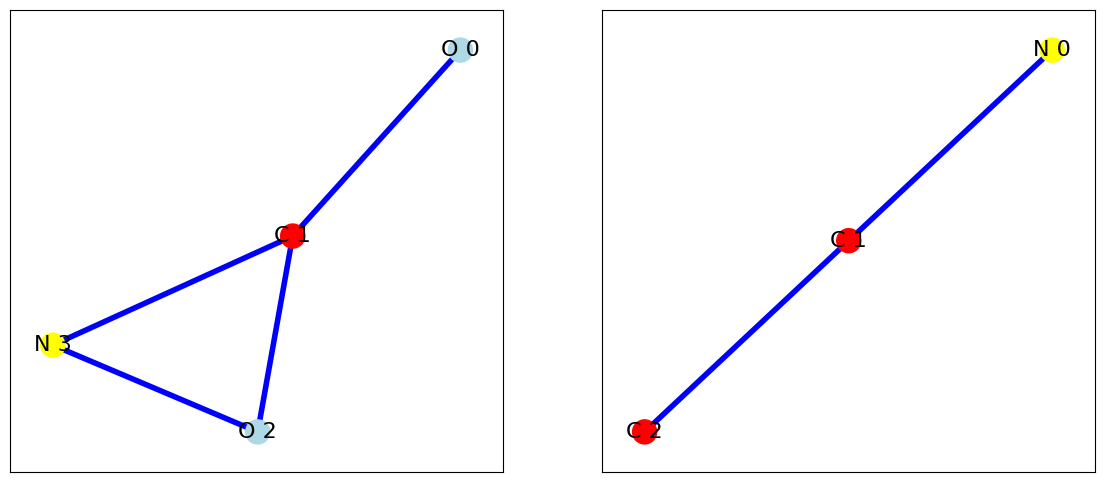

In [3]:
draw_pair_graph(g1_toy,g2_toy)

We want to compute the graph edit distance(GED) between the two graphs above.

The first simple idea to do this is to compute the tree representing the GED problem with all possible matches.

Then find a shortest path in this tree to find an optimal match corresponding to the GED value.

To compute the GED, we have 2 sets of edit operation costs defined as follows:

In [3]:
cost1 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':1,'e_sub':1,'e_del':1}
cost2 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':2,'e_sub':1,'e_del':2}

We can now calculate the tree, here with the cost1:

In [4]:
tree = make_pair_tree(g1_toy,g2_toy,cost1)

<Axes: >

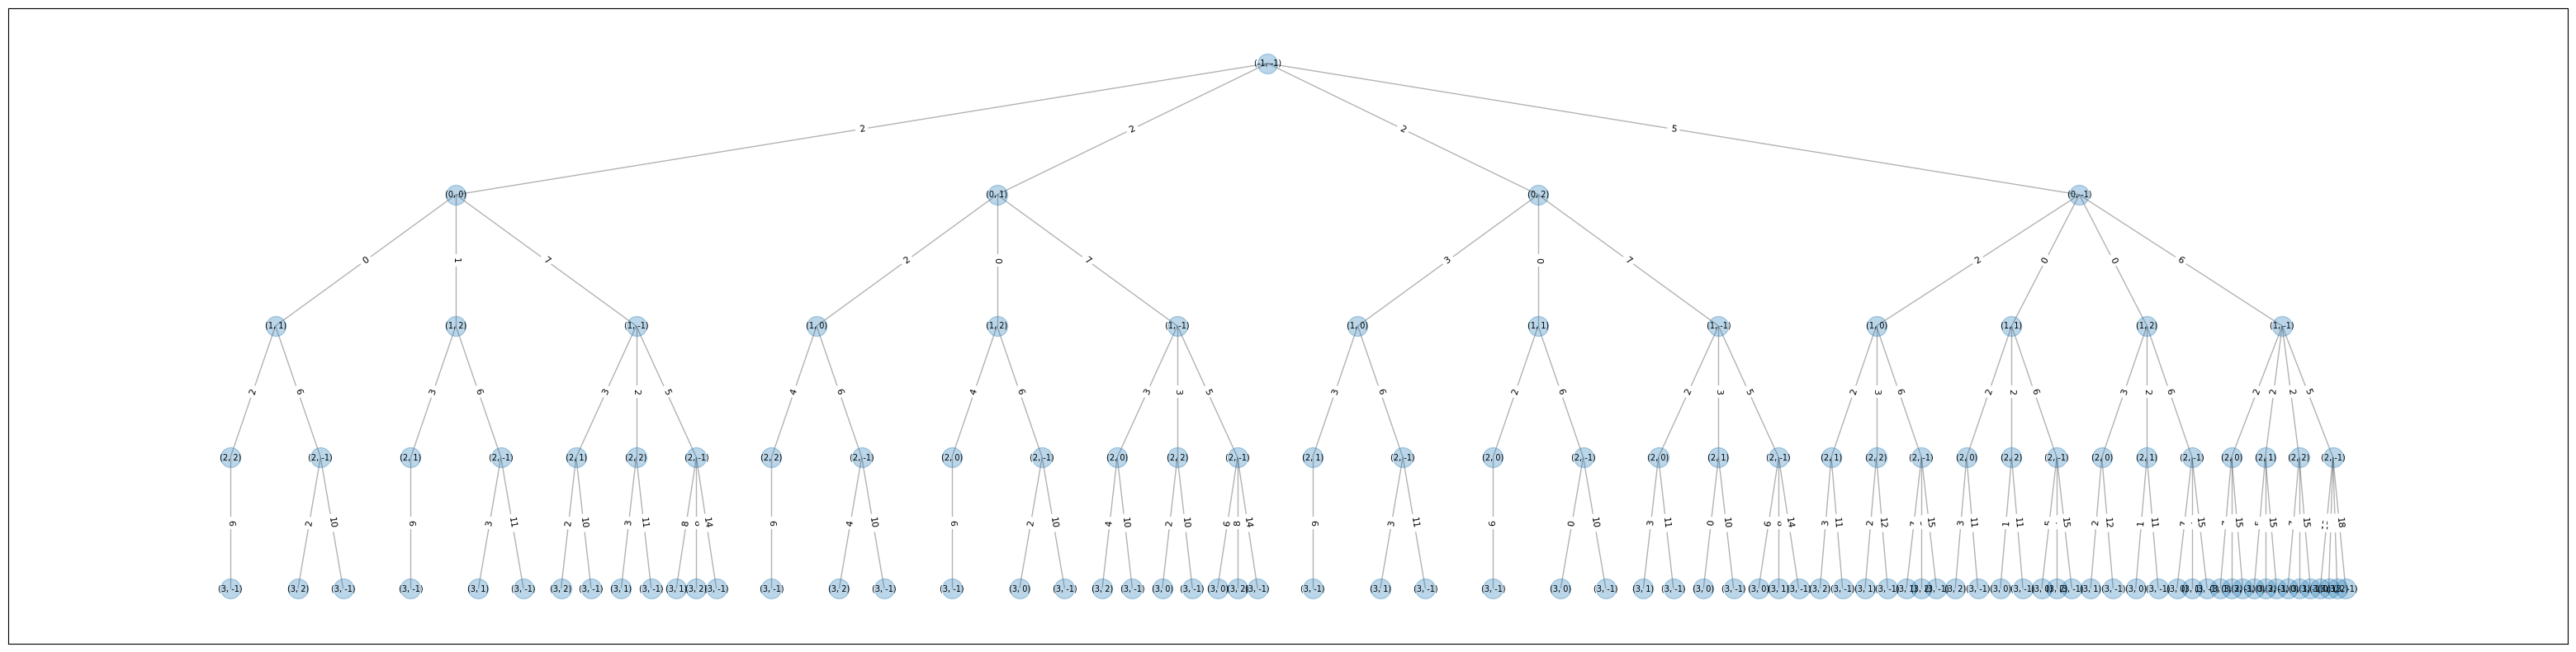

In [5]:
draw_tree(tree)

The tree above represents all possible paths to transform g1_toy into g2_toy.

We can now compute a shortest path and the cost of this path correspond to the GED value. (-1) values in a path represent either insertion or deletion.
An exemple of path : [(0,1),(-1,0),(2,-1),(3,2),(1,-1)], where the matching (i,j) is a substitution of node i whith the node j, (i,-1) a deletion of node i in the first graph and (-1,j) an insertion of node j in the second graph.
A substitution of same element have always a cost of 0 associated.

In [6]:
ged,path = path_Dijkstra(tree,g1_toy,g2_toy)
print("Graph Edit Distance value : ",ged)

Graph Edit Distance value :  8.0


In [8]:
idx_path = from_leaf_to_path(tree,path,g1_toy,g2_toy)
print("The node matching between graphs : ",idx_path)

The node matching between graphs :  [(0, 2), (1, 1), (2, -1), (3, 0)]


2 sur -1 veut dire qu'on a supprimé le noeuf 2

We get a node matching between the two graphs, which corresponds to a shortest path in the tree, all edges matching can be deduced from the node matching.

<Axes: >

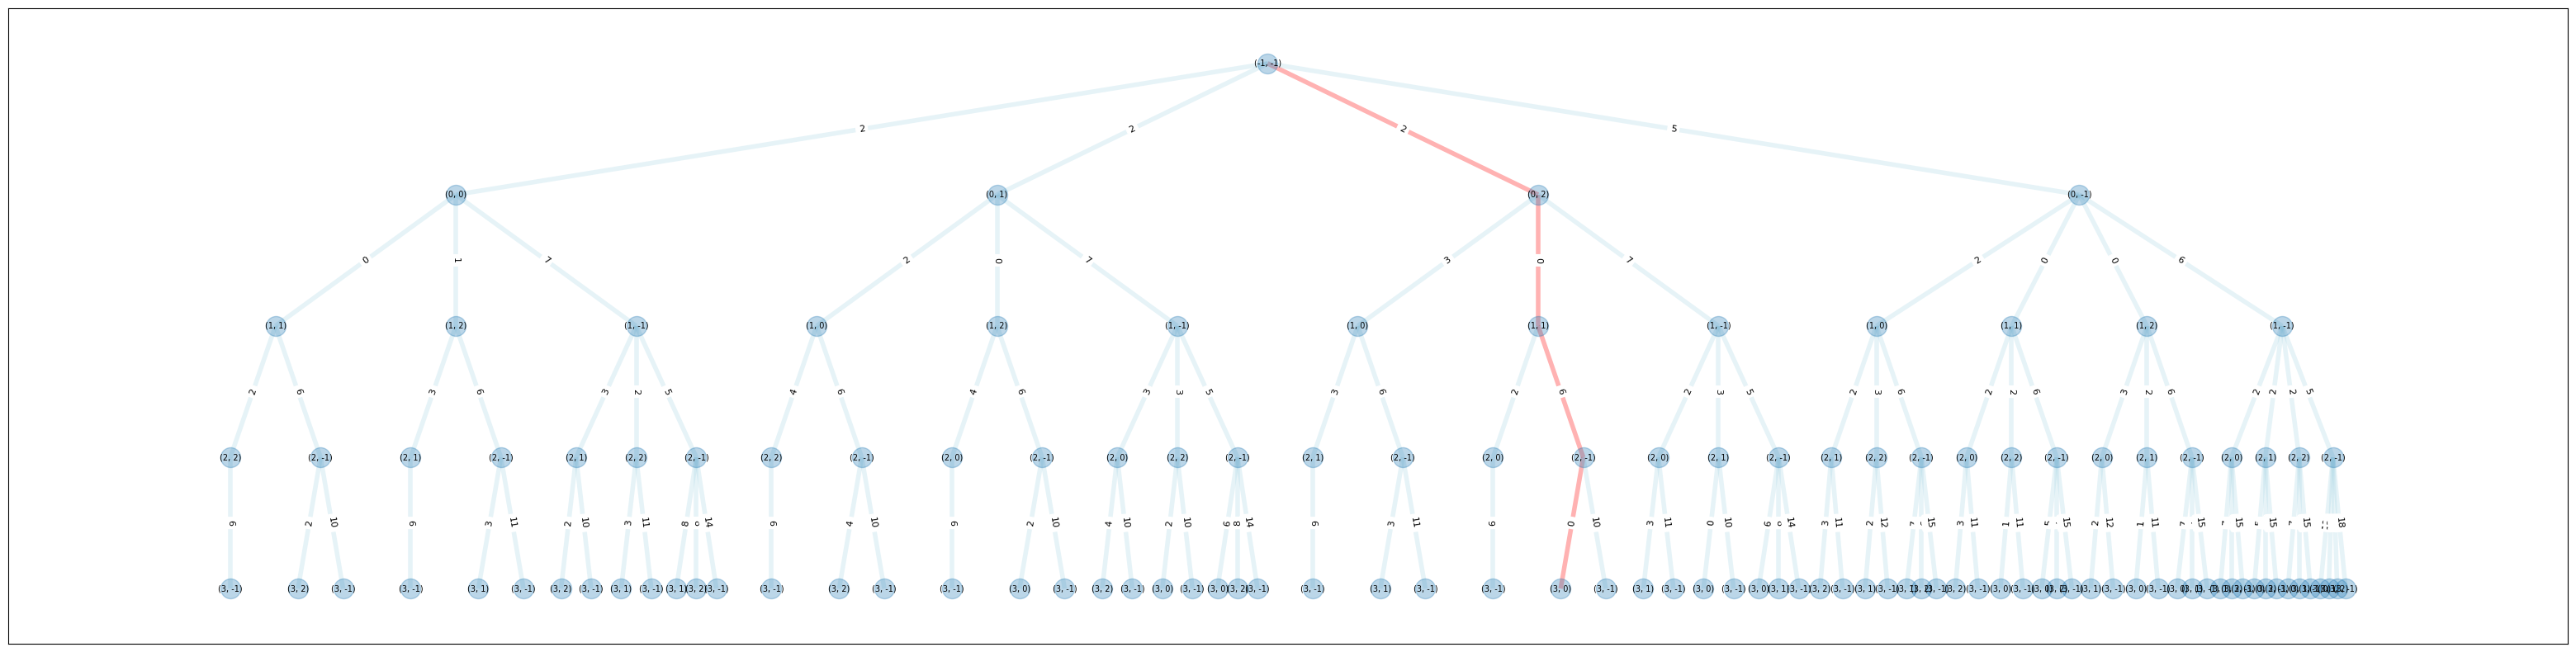

In [13]:
draw_path(tree,path)

One of the edit path that minimise the GED value is colored in red in the tree.

### Question 1) :
What are the drawbacks of this technique? and why it is not used in practise?

## 2) Astar GED :

Download the "data" file on universitice then extract its path. This file contains six graphs of chemical compounds with different atoms (nitrogen, oxygen and carbon) and different types of bonds (single, double or triple bond).

In [15]:
path = "./data"

In [16]:
data = graph_loader(path)
data

{'g0': <networkx.classes.graph.Graph at 0x22e4027a060>,
 'g1': <networkx.classes.graph.Graph at 0x22e4024f380>,
 'g2': <networkx.classes.graph.Graph at 0x22e4024cc80>,
 'g3': <networkx.classes.graph.Graph at 0x22e4024ede0>,
 'g4': <networkx.classes.graph.Graph at 0x22e4024ee40>,
 'g5': <networkx.classes.graph.Graph at 0x22e4024f320>}

You can use the draw_pair_graph() function to visualize graphs

(<Axes: >, <Axes: >)

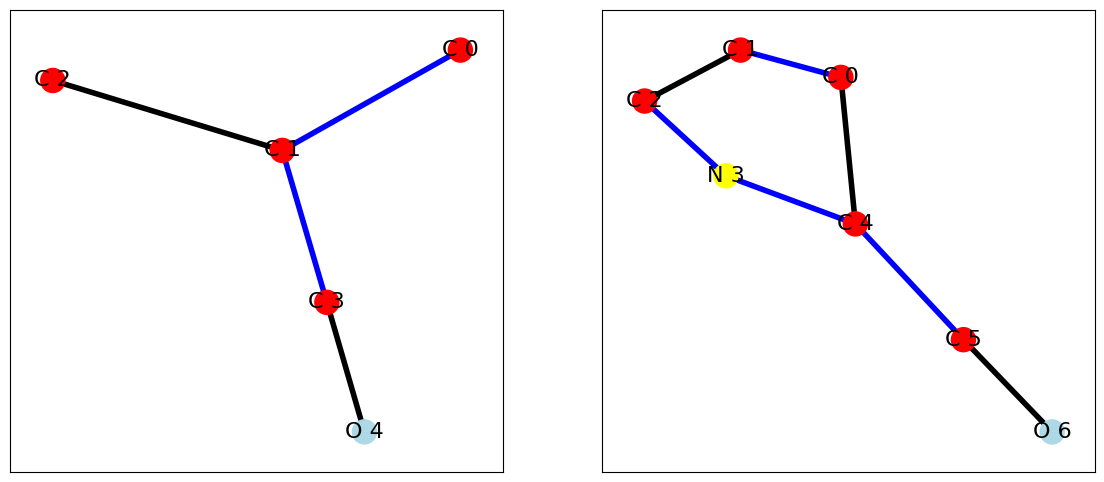

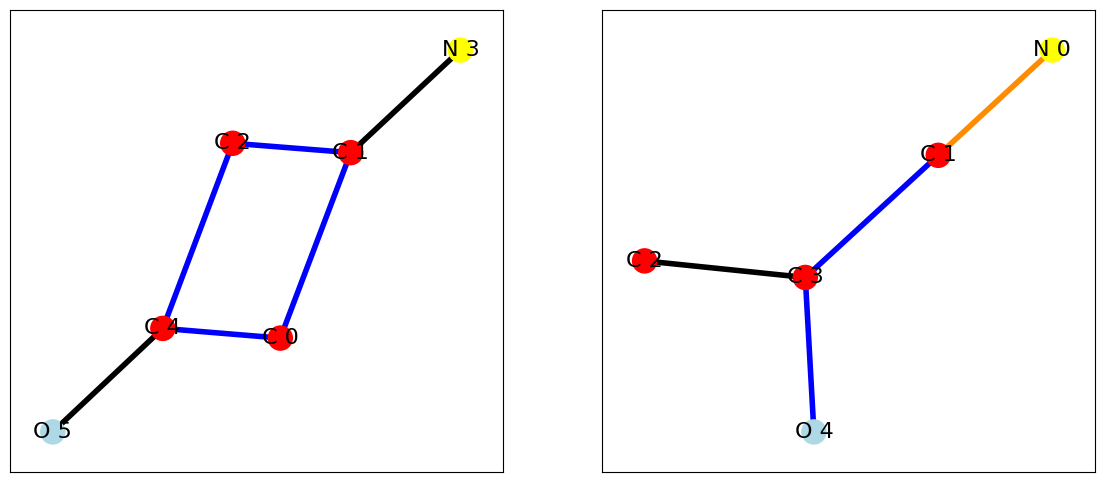

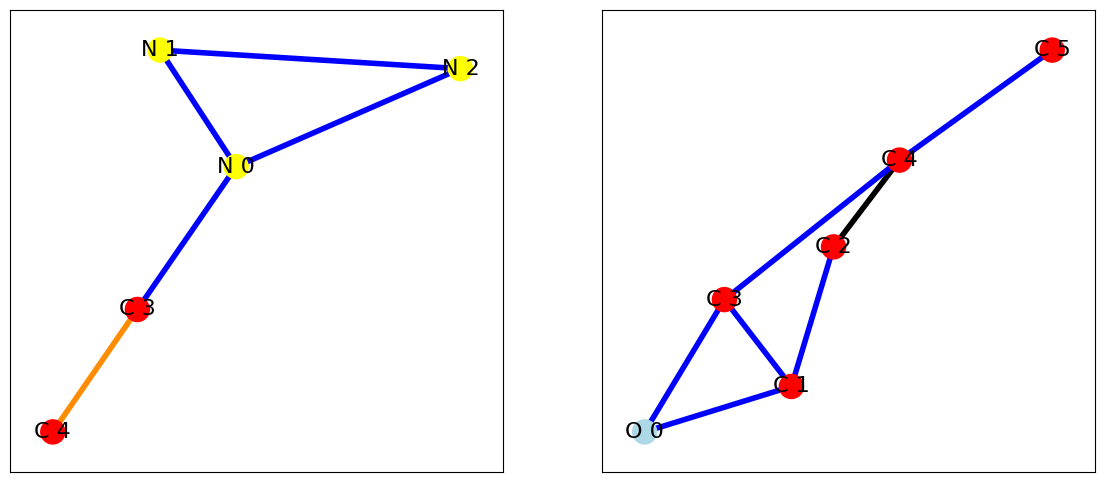

In [17]:
draw_pair_graph(data["g0"],data["g1"])
draw_pair_graph(data["g2"],data["g3"])
draw_pair_graph(data["g4"],data["g5"])

### Question 2):



First define a cost function that will compute the cost of a path. Taking account insertion, deletion and substitution of nodes and edges.

In [31]:
def cost_path(g1, g2, path, cost):
    p_cost = 0
    mapped_g1 = [u for u, v in path if u != -1]
    mapped_g2 = [v for u, v in path if v != -1]

    for u, v in path:
        if v == -1: #Suppression
            p_cost += cost['n_del']
        elif u == -1: # Insertion
            p_cost += cost['n_ins']
        else: #Substitution
            if g1.nodes[u]['node_label'] != g2.nodes[v]['node_label']:
                p_cost += cost['n_sub']
        if u != -1 and v != -1:
            for neighbor_u in g1.neighbors(u):
                # Si le voisin est déjà dans le mapping
                for prev_u, prev_v in path:
                    if neighbor_u == prev_u:
                        if prev_v != -1:
                            if not g2.has_edge(v, prev_v):
                                p_cost += cost['e_del'] + cost['e_ins'] # ou e_sub
                        else:
                            p_cost += cost['e_del']
    return p_cost

In [33]:
cost_path(data["g0"],data["g1"],data["g0"].edges,cost1)

10

We also need a function that verify if a path is complete or not.

In [34]:
def is_complete(g1,g2,path):
    return len(path) == len(g1.nodes())

Eventually the A* core function.

In [51]:
import heapq

def h_cost(g1, g2, path, cost):
    nodes_g1_mapped = [u for u, v in path if u != -1]
    nodes_g2_mapped = [v for u, v in path if v != -1] 
    rem_g1 = len(g1.nodes()) - len(nodes_g1_mapped)
    rem_g2 = len(g2.nodes()) - len(nodes_g2_mapped)

    h = 0
    if rem_g1 > rem_g2:
        h += (rem_g1 - rem_g2) * cost['n_del']
    elif rem_g2 > rem_g1:
        h += (rem_g2 - rem_g1) * cost['n_ins']
    return h


def A_star(g1, g2, cost):
    open_list = [(0, 0, [])] 
    
    nodes_g1 = list(g1.nodes())
    nodes_g2 = list(g2.nodes())
    
    while open_list:
        f, g, path = heapq.heappop(open_list)
        
        if is_complete(g1, g2, path):
            used_v2 = [v for u, v in path if v != -1]
            unused_v2 = [v for v in nodes_g2 if v not in used_v2]
            return g + len(unused_v2) * cost['n_ins'], path

        u = nodes_g1[len([u for u, v in path if u != -1])]
        
        used_v2 = [v for u_p, v in path if v != -1]
        for v in nodes_g2:
            if v not in used_v2:
                new_path = path + [(u, v)]
                new_g = cost_path(g1, g2, new_path, cost) # Coût réel
                new_h = h_cost(g1, g2, new_path, cost)    # Estimation
                heapq.heappush(open_list, (new_g + new_h, new_g, new_path))

        new_path_del = path + [(u, -1)]
        new_g_del = cost_path(g1, g2, new_path_del, cost)
        new_h_del = h_cost(g1, g2, new_path_del, cost)
        heapq.heappush(open_list, (new_g_del + new_h_del, new_g_del, new_path_del))

    return None

Check your A* function and your cost function for the toy problem and the six graphs for cost1 using the table with GED values above.

|Graph1| 	Graph2| 	GED_cost1|
| :--------------- |:---------------:| -----:|
| 	0|	1|	13.0|
| 	0| 	2| 	8.0|
| 	0| 	3| 	5.0|
| 	0| 	4| 	10.0|
| 	0| 	5| 	8.0|
| 	1| 	2| 	10.0|
|	1|	3| 	15.0|
|  1| 	4| 	17.0|
| 	1| 	5| 	11.0|
| 	2| 	3| 	10.0|
| 2| 	4| 	13.0|
| 2| 	5| 	6.0|
| 3| 	4| 	9.0|
| 3| 	5| 	11.0|
| 4| 	5| 	13.0|

In [ ]:
results_ref = {
    (0, 1): 13.0, (0, 2): 8.0, (0, 3): 5.0, (0, 4): 10.0, (0, 5): 8.0,
    (1, 2): 10.0, (1, 3): 15.0, (1, 4): 17.0, (1, 5): 11.0,
    (2, 3): 10.0, (2, 4): 13.0, (2, 5): 6.0,
    (3, 4): 9.0, (3, 5): 11.0, (4, 5): 13.0
}

print(f"{'Paire':<10} | {'Attendu':<10} | {'Calculé':<10}")
print("-" * 34)

for (i, j), val_ref in results_ref.items():
    g1 = data[f"g{i}"]
    g2 = data[f"g{j}"]
    ged_calc, _ = A_star(g1, g2, cost1)
    
    print(f"g{i} - g{j}    | {val_ref:<10} | {ged_calc:<10}")

Paire      | Attendu    | Calculé   
----------------------------------
g0 - g1    | 13.0       | 10        
g0 - g2    | 8.0        | 8         
g0 - g3    | 5.0        | 4         
g0 - g4    | 10.0       | 8         
g0 - g5    | 8.0        | 4         
g1 - g2    | 10.0       | 10        
g1 - g3    | 15.0       | 11        
g1 - g4    | 17.0       | 15        
g1 - g5    | 11.0       | 6         
g2 - g3    | 10.0       | 7         
g2 - g4    | 13.0       | 12        
g2 - g5    | 6.0        | 2         
g3 - g4    | 9.0        | 8         
g3 - g5    | 11.0       | 6         
g4 - g5    | 13.0       | 10        
